# Task 2

*Добавьте в архитектуру свёртки. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.*.

---



In [ ]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # использую gpu если есть
print(device)

cuda


In [ ]:
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor
# откалибруем данные через ToTensor, чтобы значения были в диапазоне от 0.0 до 1.0 для каждого канала
train_data = FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
) # для обучения

test_data = FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
) # для тестинга

train_data.data.shape, test_data.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

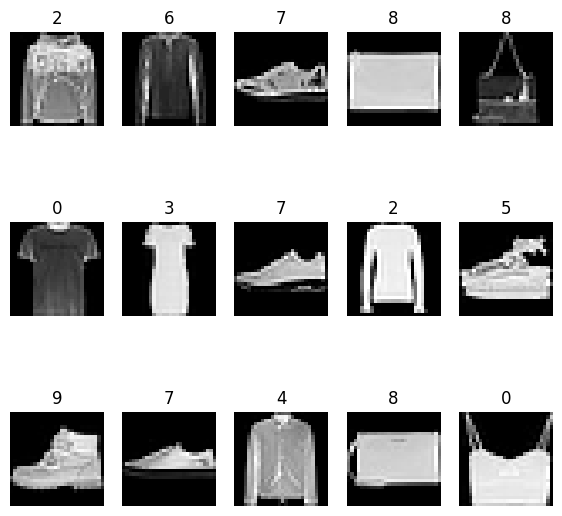

In [ ]:
import matplotlib.pyplot as plt

def visualize(data): # визуализируем датасет
  fig = plt.figure(figsize=(7, 7))

  cols, rows = 5, 3

  for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(data), size=(1,), device=device).item() # рандомная картинка, используем сразу GPU для рандома
    img, label = data[sample_idx]

    fig.add_subplot(rows, cols, i)

    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

visualize(train_data) # визуализация

In [ ]:
!pip install torchinfo

In [ ]:
from torch import nn

class ConvolutionalNeuralNetwork(nn.Module):
  def __init__(self, dropout_rate): # настройка
    super().__init__()
    self.model = nn.Sequential(
        # использую 3x3 по аналогии с VGG, который доказал эффективность
        #также, чем глубже мы идем, тем больше фильтров можно ставить

        # 1 свертка
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), # (32, 28, 28)
        nn.BatchNorm2d(32), # для каждого канала выходного тензора
        nn.ReLU(), # функция активации
        nn.MaxPool2d(kernel_size=2), # (32, 14, 14)

        # 2 свертка
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # (64, 14, 14)
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2), #(64, 7, 7)

        # 3 свертка
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), # (128, 7, 7)
        nn.BatchNorm2d(128),
        nn.ReLU(),

        # Полносвязная нейронка
        nn.Flatten(), # 128 * 7 * 7
        nn.Linear(6272, 128),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        # выходной слой
        nn.Linear(128, 10)
    )

  def forward(self, x):
    return self.model(x)


# Выведем summary модели

from torchinfo import summary

fashion_classifier = ConvolutionalNeuralNetwork(dropout_rate=0.1).to(device)
print(summary(fashion_classifier, input_size=(1, 1, 28, 28)))

Layer (type:depth-idx)                   Output Shape              Param #
ConvolutionalNeuralNetwork               [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 32, 28, 28]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 28, 28]           64
│    └─ReLU: 2-3                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-4                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-5                       [1, 64, 14, 14]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 14, 14]           128
│    └─ReLU: 2-7                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-8                    [1, 64, 7, 7]             --
│    └─Conv2d: 2-9                       [1, 128, 7, 7]            73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 7, 7]            256
│    └─ReLU: 2-11                        [1, 128, 7, 7]            --
│   

In [ ]:
from torch import optim
from torch.utils.data import DataLoader

optimizer = torch.optim.SGD(fashion_classifier.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

import os
# разделим данные на батчи
batch_size = 256
num_of_epochs = 100

num_workers = min(8, os.cpu_count()) # для многопоточности

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True) # обучающая выборка
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True) # тестовая выборка

# persistent_workers позволяет переиспользовать потоки
# pinned_memory позволяет использовать область памяти ОЗУ которая не выгружает ее в диск

In [ ]:
!pip install pytorch-ignite

In [ ]:
from ignite.engine import create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss, Precision, Recall, Fbeta

trainer = create_supervised_trainer(fashion_classifier, optimizer, criterion, device)

metrics = {
    "accuracy": Accuracy(),
    "precision": Precision(average=True),
    "recall": Recall(average=True),
    "f1_score": Fbeta(average=True, beta=1.0),
    "loss": Loss(criterion)
}

train_evaluator = create_supervised_evaluator(fashion_classifier, metrics=metrics, device=device) # проверка на обучающей выборке
test_evaluator = create_supervised_evaluator(fashion_classifier, metrics=metrics, device=device) # проверка на тестовой выборке

/usr/local/lib/python3.10/dist-packages/ignite/handlers/checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


In [ ]:
from IPython.display import clear_output

def show_loss(train_losses, test_losses, train_accuracies, test_accuracies):
  clear_output()

  plt.figure(figsize=(15,15))

  plt.subplot(2, 2, 1)
  plt.title('Train Loss')
  plt.plot(np.arange(len(train_losses)), train_losses)  # лосс обучающей выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(2, 2, 2)
  plt.title('Test Loss')
  plt.plot(np.arange(len(test_losses)), test_losses) # лосс тестовой выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(2, 2, 3)
  plt.title('Train Accuracy')
  plt.plot(np.arange(len(train_accuracies)), train_accuracies) # accuracy обучающей выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(2, 2, 4)
  plt.title('Test Accuracy')
  plt.plot(np.arange(len(test_accuracies)), test_accuracies) # accuracy тестовой выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.show()


In [ ]:
from ignite.engine import Events


train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

test_y_true = []
test_y_pred = []

experiment = []

best_avg_error, best_epoch = float("inf"), 0

def compute_epoch_results(engine):
    global best_avg_error, best_epoch, experiment
    train_evaluator.run(train_loader)
    test_evaluator.run(test_loader)
    # Сохраняем метрики
    train_losses.append(train_evaluator.state.metrics["loss"])
    test_losses.append(test_evaluator.state.metrics["loss"])
    train_accuracies.append(train_evaluator.state.metrics["accuracy"])
    test_accuracies.append(test_evaluator.state.metrics["accuracy"])

    if test_losses[-1] < best_avg_error: # проверяем есть ли какие-либо улучшения
        best_avg_error = test_losses[-1]
        experiment = [{
            "Min Validation Loss": best_avg_error,
            "Accuracy": test_evaluator.state.metrics["accuracy"],
            "Precision": test_evaluator.state.metrics["precision"],
            "Recall": test_evaluator.state.metrics["recall"],
            "F1-score": test_evaluator.state.metrics["f1_score"]
        }]

trainer.add_event_handler(Events.EPOCH_COMPLETED, compute_epoch_results)


trainer.add_event_handler(
    Events.EPOCH_COMPLETED(every=10),
    lambda engine: show_loss(train_losses, test_losses, train_accuracies, test_accuracies)
)

def log_epoch_results(engine, label=""):
    result = ', '.join([f"{m} = {v}" for m, v in engine.state.metrics.items()])
    print(f"{label} Res:", result)

train_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Train")
test_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Valid")

In [ ]:
from ignite.handlers.param_scheduler import ReduceLROnPlateauScheduler
from ignite.handlers import EarlyStopping

scheduler = ReduceLROnPlateauScheduler(
    optimizer,
    mode='min',
    metric_name="loss",
    factor=0.1,
    patience=5,
    threshold=0.05
)

test_evaluator.add_event_handler(Events.COMPLETED, scheduler) # снижает lr у оптимайзера, если не было улучшений

early_stopping = EarlyStopping(patience=10, score_function=lambda x: -test_evaluator.state.metrics["loss"] , trainer=trainer) # для своевременной остановки если не было улучшений

test_evaluator.add_event_handler(Events.COMPLETED, early_stopping) # если при запуске валидации не было улучшений останавливаем

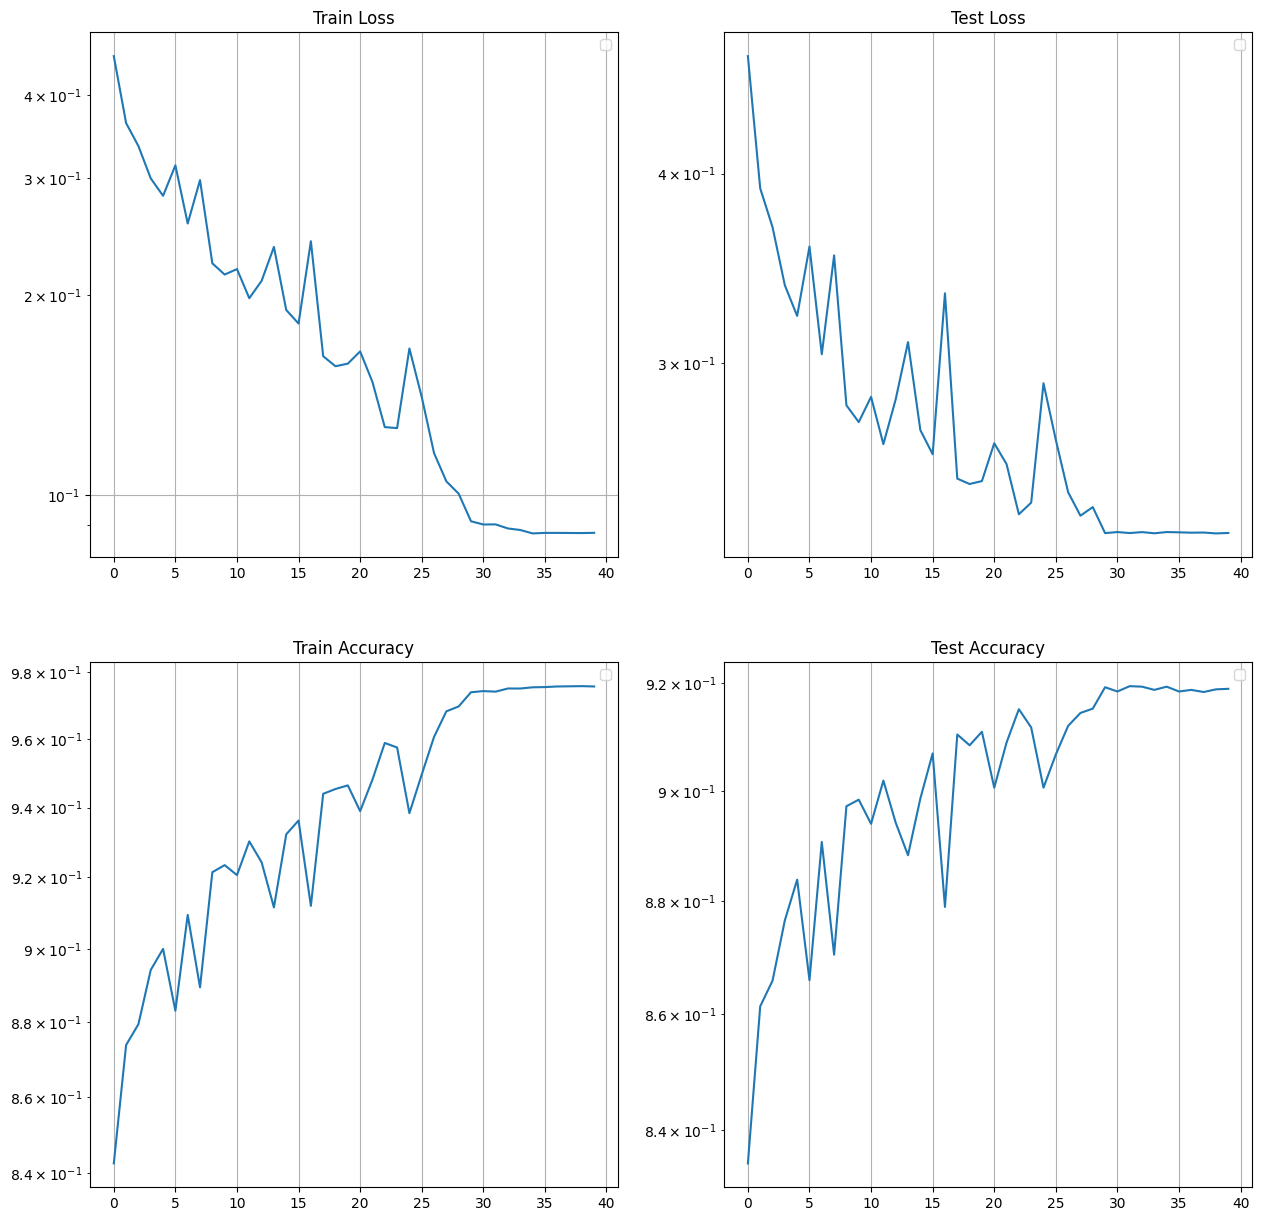

Train Res: accuracy = 0.9756833333333333, precision = 0.9756593091759734, recall = 0.9756833333333332, f1_score = 0.9756362867474182, loss = 0.08734191080729167
Valid Res: accuracy = 0.9191, precision = 0.9188547927961352, recall = 0.9190999999999999, f1_score = 0.9189280403516186, loss = 0.23143486328125
Train Res: accuracy = 0.9757833333333333, precision = 0.9757718637300814, recall = 0.9757833333333332, f1_score = 0.9757348655457209, loss = 0.08698107096354167
Valid Res: accuracy = 0.9188, precision = 0.9185031364250259, recall = 0.9187999999999998, f1_score = 0.9186004978208594, loss = 0.2319348876953125
Train Res: accuracy = 0.9757666666666667, precision = 0.9757473078205938, recall = 0.9757666666666666, f1_score = 0.9757248459525606, loss = 0.08756038411458333
Valid Res: accuracy = 0.9185, precision = 0.918245045758573, recall = 0.9185000000000001, f1_score = 0.9183246527268614, loss = 0.2316051025390625
Train Res: accuracy = 0.9756833333333333, precision = 0.9756585283096516, re

2025-03-25 18:36:36,589 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Valid Res: accuracy = 0.9186, precision = 0.9183273948582589, recall = 0.9186, f1_score = 0.9184143832869498, loss = 0.231716748046875


State:
	iteration: 11515
	epoch: 49
	epoch_length: 235
	max_epochs: 100
	output: 0.12711399793624878
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

In [ ]:
trainer.run(train_loader, max_epochs=num_of_epochs)

# Test Loss:

На графике функции потерь для тестовой выборки видно, что на первых эпохах функция резко падает, особенно в первые 10 эпох, но присутствуют колебания примерно после 4 эпохи. После 10-й эпохи спад становится менее заметным, с некоторыми колебаниями которые напоминают взрывные скачки, что может быть связано с адаптацией модели к данным. С 20-й по 30-ю эпоху функция потерь колеблется в такой же взрывной форме, но общая тенденция остается убывающей. Начиная с 30-й эпохи, модель стабилизируется, и значение функции потерь продолжает уменьшаться, но уже более плавно, что указывает на достижение модели оптимума.

# Test Accuracy:

Точность на тестовой выборке постепенно растет с каждой эпохой. Начиная с первых 5 эпох точность увеличивается, что свидетельствует о том, что модель эффективно обучается на данных. С 10-й по 25-ю эпоху точность продолжает улучшаться с некоторыми взрывными скачками, что может указывать на небольшое переобучение. Однако с 25-й по 35-ю эпоху точность стабилизируется и продолжает уверенно расти, достигая значения около 0.92. Модель успешно обобщилась на тестовых данных и решает задачу лучше, чем полносвязная нейронная сеть.

In [ ]:
import pandas as pd

report = pd.DataFrame(experiment)

print(report)

   Min Validation Loss  Accuracy  Precision  Recall  F1-score
0             0.231429    0.9188   0.918612  0.9188  0.918669


# Вывод:

Теперь, с добавлением сверток, модель улучшилась на ~4%, значительно эффективнее решая задачу. Это подтверждает, что сверточные нейронные сети эффективно решают задачу, обеспечивая лучший результат на тестовых данных.

Полагаю, добавление аугментации позволит улучшить обобщающие качества модели и поможет ей стабилизироваться.

Отчет:


 |Min Validation Loss | Accuracy | Precision | Recall |  F1-score |
 |--------------------|----------|-----------|--------|-----------|
 |          0.231429  |   0.9188  | 0.918612   | 0.9188 | 0.918669   |

